In [2]:
import numpy as np
import sys
import os
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass

In [3]:
sys.path.append(os.path.abspath('../library'))
import data as d
import preprocess as p
import utils as u
import bayes as b
import pipeline
import results as r
import figures as figs

In [4]:
mouse_ID = 'C57_915_Serena'
Serena_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Serena_200.tau = 0.2 # size of time bin of the data in seconds
Serena_200.rewardzone = [46,47,48,49]

scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/time_binned_SpikeInf_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/time_binned_DiscreteSpikes_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/target_positions_200msbins.mat loaded with mat73.loadmat
../datafiles/C57_915_Serena/darktrial_raw.mat loaded with scipy.io.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/del_trials.mat loaded with mat73.loadmat

Data of: C57_915_Serena

Spike Probability:
(272, 79, 44)
Trial x Time Bin x Neuron

Discrete Spikes:
(272, 79, 44)
Trial x Time Bin x Neuron

Position Matrices:
(272

In [5]:
Serena_200.posterior_chunks, Serena_200.decoded_pos_chunks = pipeline.run_decoder_chunks(Serena_200, smoothfactor=0.2)
Serena_200.results_allchunks = pipeline.run_results_chunks(Serena_200, Serena_200.posterior_chunks, Serena_200.decoded_pos_chunks, 46, 10)

1. Masking spikes and position matrix.
smallest first position: 0.0
largest first position: 34.0
2. Getting trial length.
3. Smoothing spikes.
sigma: 1.0, smoothfactor: 0.2
4. Position Binning data and generating firing rates.


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


5. Splitting light vs dark.
6. Scaling firing rates.
higher in dark: 20 | 45.45454545454545 %
higher in light: 24 | 54.54545454545454 %
higher in dark: 20 | 45.45454545454545 %
higher in light: 24 | 54.54545454545454 %
Sorting trials and chunking trials.
(18, 79, 44)
(18, 79, 44)
(18, 79, 44)
(18, 79, 44)
(18, 79, 44)
(18, 79, 44)
(17, 79, 44)
(17, 79, 44)
(17, 79, 44)
(17, 79, 44)
(10, 79, 44)
(10, 79, 44)
(10, 79, 44)
(10, 79, 44)
(10, 79, 44)
(10, 79, 44)
(9, 79, 44)
(9, 79, 44)
(9, 79, 44)
(9, 79, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(17, 50, 44)
(17, 50, 44)
(17, 50, 44)
(17, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(9, 50, 44)
(9, 50, 44)
(9, 50, 44)
(9, 50, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(18, 50, 44)
(17, 50, 44)
(17, 50, 44)
(17, 50, 44)
(17, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(10, 50, 44)
(9, 50, 44)
(9, 50, 44)
(

/Users/andrewlau/code/bayesian_decoder/library/bayes.py:235: RuntimeWarning: Mean of empty slice
  fx = np.nanmean(firingrate, axis=0)        # mean firing rate across trials
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:237: RuntimeWarning: divide by zero encountered in log
  log_lamb = np.log(lamb)                    # log lambda
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:253: RuntimeWarning: invalid value encountered in scalar multiply
  log_pnx_before_sum[t,x,i] = (n_i * log_lamb[x,i]) - lamb[x,i] - log_nfac[t,i]
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:273: RuntimeWarning: divide by zero encountered in log
  log_pn = np.log(np.sum((pnx * px), axis=1))
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:279: RuntimeWarning: invalid value encountered in subtract
  posterior_chunk[test_trial] = np.exp((log_pnx.T + log_px - log_pn).T)
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:286: RuntimeWarning: All-NaN slice encountered
  if np

Chunk  0  lgtlgt completed.


/Users/andrewlau/code/bayesian_decoder/library/bayes.py:223: RuntimeWarning: invalid value encountered in log
  log_px = np.log(px)
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:273: RuntimeWarning: invalid value encountered in log
  log_pn = np.log(np.sum((pnx * px), axis=1))


Chunk  0  drkdrk completed.
Chunk  0  lgtdrk completed.
Chunk  0  drklgt completed.
Decoding chunk  1 ...
Chunk  1  lgtlgt completed.
Chunk  1  drkdrk completed.
Chunk  1  lgtdrk completed.
Chunk  1  drklgt completed.
Decoding chunk  2 ...
Chunk  2  lgtlgt completed.
Chunk  2  drkdrk completed.
Chunk  2  lgtdrk completed.
Chunk  2  drklgt completed.
Decoding chunk  3 ...
Chunk  3  lgtlgt completed.
Chunk  3  drkdrk completed.
Chunk  3  lgtdrk completed.
Chunk  3  drklgt completed.
Decoding chunk  4 ...
Chunk  4  lgtlgt completed.
Chunk  4  drkdrk completed.
Chunk  4  lgtdrk completed.
Chunk  4  drklgt completed.
Decoding chunk  5 ...
Chunk  5  lgtlgt completed.
Chunk  5  drkdrk completed.
Chunk  5  lgtdrk completed.
Chunk  5  drklgt completed.
Decoding chunk  6 ...
Chunk  6  lgtlgt completed.
Chunk  6  drkdrk completed.
Chunk  6  lgtdrk completed.
Chunk  6  drklgt completed.
Decoding chunk  7 ...
Chunk  7  lgtlgt completed.
Chunk  7  drkdrk completed.
Chunk  7  lgtdrk completed.
Chunk 

/Users/andrewlau/code/bayesian_decoder/library/results.py:338: RuntimeWarning: invalid value encountered in scalar divide
  accuracy_rate_chunk = np.sum(accuracy_mtx) / (len(accuracy_mtx))


ValueError: zero-size array to reduction operation fmin which has no identity

In [ ]:
# Check whether the decoded positions are all NaNs for a specific chunk

for chunk in range(10):
    for paradigm in Serena_200.decoded_pos_chunks[chunk]:
        print(chunk, paradigm, np.all(np.isnan(Serena_200.decoded_pos_chunks[chunk][paradigm])))

0 lgtlgt False
0 drkdrk False
0 lgtdrk False
0 drklgt False
1 lgtlgt True
1 drkdrk False
1 lgtdrk True
1 drklgt False
2 lgtlgt True
2 drkdrk True
2 lgtdrk True
2 drklgt True
3 lgtlgt True
3 drkdrk True
3 lgtdrk True
3 drklgt True
4 lgtlgt False
4 drkdrk True
4 lgtdrk False
4 drklgt True
5 lgtlgt False
5 drkdrk True
5 lgtdrk False
5 drklgt True
6 lgtlgt True
6 drkdrk False
6 lgtdrk True
6 drklgt False
7 lgtlgt False
7 drkdrk True
7 lgtdrk False
7 drklgt True
8 lgtlgt True
8 drkdrk True
8 lgtdrk True
8 drklgt True
9 lgtlgt False
9 drkdrk True
9 lgtdrk False
9 drklgt True


[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
(18, 79)
(18, 79)
(18, 79)
(18, 79)
(18, 79)
(18, 79)
(17, 79)
(17, 79)
(17, 79)
(17, 79)
(10, 79)
(10, 79)
(10, 79)
(10, 79)
(10, 79)
(10, 79)
(9, 79)
(9, 79)
(9, 79)
(9, 79)


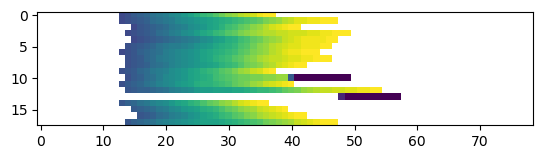

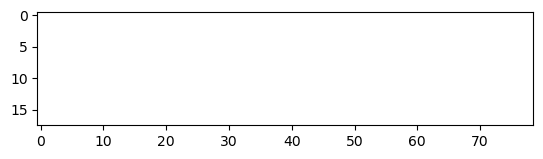

ValueError: zero-size array to reduction operation fmin which has no identity

In [ ]:
mouse = Serena_200
paradigm = 'lgtlgt'
num_chunks = 10
chunk_idx = 1
decoded_pos_chunk = Serena_200.decoded_pos_chunks[chunk_idx][paradigm]
print(decoded_pos_chunk)


# Chunk position matrix
pos_light, pos_dark = u.split_lightdark(mouse.position_mtx_masked, mouse.darktrials)
pos_light_sorted = u.sort_trialstart(pos_light, mouse.position_mtx, mouse.darktrials, 'light')
pos_dark_sorted = u.sort_trialstart(pos_dark, mouse.position_mtx, mouse.darktrials, 'dark')
pos_light_chunks = u.chunk_trials(pos_light_sorted, num_chunks)
pos_dark_chunks = u.chunk_trials(pos_dark_sorted, num_chunks)

# Specify true position
if paradigm == 'lgtlgt' or paradigm == 'drklgt':  
    true = pos_light_chunks[chunk_idx]
elif paradigm == 'drkdrk' or paradigm == 'lgtdrk':    
    true = pos_dark_chunks[chunk_idx]

plt.imshow(true)
plt.show()

plt.imshow(decoded_pos_chunk)
plt.show()

# Create a mask for time bins where there are decoder predictions
predictions = ~np.isnan(decoded_pos_chunk)

# Absolute errors between decoded position and true positions, taking into
# consideration only the time bins where decoded position is non-NaN
errors_chunk = abs(np.subtract(decoded_pos_chunk[predictions], true[predictions]))

min_error = np.nanmin(errors_chunk)
max_error = np.nanmax(errors_chunk)
mean_error = np.nanmean(errors_chunk)

sqr_error = np.square(errors_chunk)    
mse_chunk = np.nansum(sqr_error) / len(sqr_error)
rt_mse_chunk = np.sqrt(mse_chunk)

print(errors_chunk.shape)
print("min error:", min_error, "position bins (10cm)")
print("max error:", max_error, "position bins (10cm)")
print("mean error:", mean_error, "position bins (10cm)")
print()
print("mean squared error:", mse_chunk)
print("root mean suqred error:", rt_mse_chunk, "position bins (10cm)")

#### 0. Load data

In [3]:
spikeprob, spikes, position_mtx, darktrials, deltrials = d.load_data('C57_915_Serena', tau=0.2)

scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/time_binned_SpikeInf_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/time_binned_DiscreteSpikes_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/target_positions_200msbins.mat loaded with mat73.loadmat
../datafiles/C57_915_Serena/darktrial_raw.mat loaded with scipy.io.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_915_Serena/del_trials.mat loaded with mat73.loadmat


#### 1. Align axes

In [4]:
spikeprob, spikes, darktrials = p.align_axes(spikeprob, spikes, darktrials)

print(spikeprob.shape)
print(spikes.shape)
print(darktrials.shape)

(295, 79, 46)
(295, 79, 46)
(295, 1)


In [5]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.003771428933174647
mean in light: 0.004162648501138766
mean in dark: 0.003141015043808894
31 out of 46 are higher in light

Spikeprob
mean all: 0.018399894248672555
mean in light: 0.0162412111765629
mean in dark: 0.021948031189523626
17 out of 46 are higher in light


#### 2. Format position index and Remove deleted trials

In [55]:
# Priamus
deltrials = np.append(deltrials, [79, 157])

In [6]:
position_mtx, deltrials = p.format_pos_idx(position_mtx, deltrials)
spikeprob, spikes, position_mtx, darktrials = p.remove_deleted_trials(spikeprob, spikes, position_mtx, darktrials, deltrials)

print(spikeprob.shape)
print(spikes.shape)
print(position_mtx.shape)
print(darktrials.shape)
print(deltrials.shape)

(272, 79, 46)
(272, 79, 46)
(272, 79)
(272, 1)
(23,)


In [7]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.003166594920361601
mean in light: 0.002955710904628331
mean in dark: 0.0035235101579088896
24 out of 46 are higher in light

Spikeprob
mean all: 0.018149143378371774
mean in light: 0.01609561285943133
mean in dark: 0.021657776012411763
17 out of 46 are higher in light


#### 3. Remove non-nan neurons, match nans, and correct pos artefacts

In [8]:
spikeprob, spikes = p.remove_nonnan_neuron(spikeprob, spikes)
spikes = p.match_nan_from_spikeprob(spikeprob, spikes)
position_mtx = p.remove_pos_artefacts(position_mtx)

print(spikeprob.shape)
print(spikes.shape)
print(position_mtx.shape)

(272, 79, 44)
(272, 79, 44)
(272, 79)


In [9]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.004211576293258707
mean in light: 0.0039056208729263972
mean in dark: 0.004734327312753289
22 out of 44 are higher in light

Spikeprob
mean all: 0.018687704746584353
mean in light: 0.016521063118978913
mean in dark: 0.02238959738989809
15 out of 44 are higher in light


#### 4. Masking spikes

In [10]:
rewardzone = [46,47,48,49]
firstx_pos = u.get_firstx_pos(position_mtx, 5)
mask = u.create_spikesmask(spikes, position_mtx, spikeprob, rewardzone, firstx_pos)
position_mtx_masked = u.mask_position_mtx(position_mtx, rewardzone, firstx_pos)
print(np.nanmin(position_mtx_masked))
print(np.nanmax(position_mtx_masked))

spikes_masked = u.mask_spikes(spikes, mask)
spikeprob_masked = u.mask_spikes(spikeprob, mask)

smallest first position: 0.0
largest first position: 34.0
0.0
45.0


In [11]:
num_light_higher_spikes = 0
num_light_higher_spikeprob = 0

num_neurons = spikes.shape[2]

spikes_light, spikes_dark = u.split_lightdark(spikes, darktrials)
spikeprob_light, spikeprob_dark = u.split_lightdark(spikeprob, darktrials)

for neuron in range(num_neurons):
    mean_spikes_light = np.nanmean(spikes_light[:,:,neuron])
    mean_spikes_dark = np.nanmean(spikes_dark[:,:,neuron])

    mean_spikeprob_light = np.nanmean(spikeprob_light[:,:,neuron])
    mean_spikeprob_dark = np.nanmean(spikeprob_dark[:,:,neuron])

    spikes_compare = mean_spikes_light - mean_spikes_dark
    spikeprob_compare = mean_spikeprob_light - mean_spikeprob_dark

    if spikes_compare > 0:
        num_light_higher_spikes += 1

    if spikeprob_compare > 0:
        num_light_higher_spikeprob += 1

print("Spikes")
print("mean all:", np.nanmean(spikes))
print("mean in light:", np.nanmean(spikes_light))
print("mean in dark:", np.nanmean(spikes_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikes, num_neurons))
print()
print("Spikeprob")
print("mean all:", np.nanmean(spikeprob))
print("mean in light:", np.nanmean(spikeprob_light))
print("mean in dark:", np.nanmean(spikeprob_dark))
print("{} out of {} are higher in light".format(num_light_higher_spikeprob, num_neurons))

Spikes
mean all: 0.004211576293258707
mean in light: 0.0039056208729263972
mean in dark: 0.004734327312753289
22 out of 44 are higher in light

Spikeprob
mean all: 0.018687704746584353
mean in light: 0.016521063118978913
mean in dark: 0.02238959738989809
15 out of 44 are higher in light


#### Plot single tuning

In [18]:
neuron_idx = np.random.randint(0, num_neurons)
# neuron_idx = 83
# neuron_idx = 29
# neuron_idx = 109
print(neuron_idx)

10


In [ ]:
fr = u.posbinning_data(spikes_masked, 'spikes', position_mtx_masked, 50, 0.2)
fr_light, fr_dark = u.split_lightdark(fr, darktrials)

spikeprob_pbin = u.posbinning_data(spikeprob_masked, 'spikeprob', position_mtx_masked, 50, 0.2)
spikeprob_pbin_light, spikeprob_pbin_dark = u.split_lightdark(spikeprob_pbin, darktrials)


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


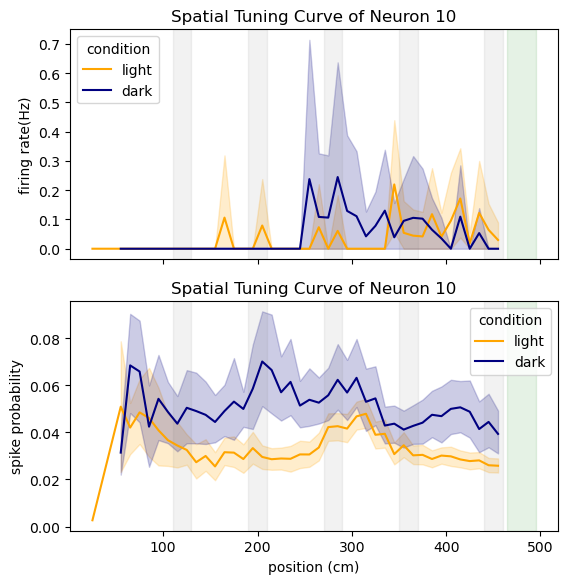

In [19]:
fr = u.posbinning_data(spikes_masked, 'spikes', position_mtx_masked, 50, 0.2)
num_trials, num_pbins, num_neurons = fr.shape
fr_light, fr_dark = u.split_lightdark(fr, darktrials)

# Generate Data Frame
position_all_spikes = np.tile(np.arange(num_pbins), fr.shape[0])
condition_all_spikes = np.array(
    ['light'] * fr_light.shape[0] * num_pbins + 
    ['dark'] * fr_dark.shape[0] * num_pbins
)
data_all_spikes = np.concatenate(
    (fr_light[:,:,neuron_idx].flatten(), 
        fr_dark[:,:,neuron_idx].flatten())
)    
df_spikes = pd.DataFrame(
    {'position':position_all_spikes, 'condition':condition_all_spikes, 'activity':data_all_spikes}
)


spikeprob_pbin = u.posbinning_data(spikeprob_masked, 'spikeprob', position_mtx_masked, 50, 0.2)
num_trials, num_pbins, num_neurons = spikeprob_pbin.shape
spikeprob_pbin_light, spikeprob_pbin_dark = u.split_lightdark(spikeprob_pbin, darktrials)

# Generate Data Frame
position_all_spikeprob = np.tile(np.arange(num_pbins), spikeprob_pbin.shape[0])
condition_all_spikeprob = np.array(
    ['light'] * spikeprob_pbin_light.shape[0] * num_pbins + 
    ['dark'] * spikeprob_pbin_dark.shape[0] * num_pbins
)
data_all_spikeprob = np.concatenate(
    (spikeprob_pbin_light[:,:,neuron_idx].flatten(), 
        spikeprob_pbin_dark[:,:,neuron_idx].flatten())
)    
df_spikeprob = pd.DataFrame(
    {'position':position_all_spikeprob, 'condition':condition_all_spikeprob, 'activity':data_all_spikeprob}
)




# Initialise figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,6), sharex=True)
fig.tight_layout(pad=2.5, h_pad=2)

# Initialise figure settings
ax_settings = {'title':'Spatial Tuning Curve of Neuron {}'.format(neuron_idx), 
                'xlabel':'position (cm)',
                'xticks':[-0.5, 9.5, 19.5, 29.5, 39.5, 49.5],
                'xticklabels':[0, 100, 200, 300, 400, 500]}

# Plot
ax1 = sns.lineplot(data=df_spikes, x ='position', y='activity', hue='condition', palette=['orange','navy'], ax=ax1)
ax2 = sns.lineplot(data=df_spikeprob, x ='position', y='activity', hue='condition', palette=['orange','navy'], ax=ax2)


ax1.set(ylabel = 'firing rate(Hz)', **ax_settings)
ax2.set(ylabel ='spike probability', **ax_settings)



# Specify landmarks and reward zones
landmark = [(10.5,12.5), (18.5,20.5), (26.5,28.5), (34.5,36.5), (43.5,45.5)]
rewardzone = (46, 49)

for coord in landmark:
    ax1.axvspan(coord[0], coord[1], alpha=0.1, color='grey')
    ax2.axvspan(coord[0], coord[1], alpha=0.1, color='grey')

ax1.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')
ax2.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')

ax1.axvline(0, linewidth=1, color="white")
ax2.axvline(0, linewidth=1, color="white")

    
plt.show()

In [65]:
np.nanmean(fr_dark[:,:,109], axis=0)

/var/folders/f6/9tvrjkdn24b4mjg8c_xtrc8c0000gn/T/ipykernel_42358/2027586448.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean(fr_dark[:,:,109], axis=0)


array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan, 0.        ,
       1.        , 2.91666667, 0.        , 2.        , 0.625     ,
       1.25      , 0.5       , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.18518519, 0.        ,
       0.        , 0.        , 0.57142857, 0.3125    , 0.32258065,
       0.29411765, 0.37878788, 0.        , 0.        , 0.27027027,
       0.73529412, 0.30701754, 0.76923077, 1.01190476, 0.13157895,
       0.375     , 0.12820513, 0.31914894, 0.13333333, 0.        ,
       0.12681159,        nan,        nan,        nan,        nan])

In [64]:
np.nanmean(fr_light[:,:,109], axis=0)

/var/folders/f6/9tvrjkdn24b4mjg8c_xtrc8c0000gn/T/ipykernel_42358/3408101052.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean(fr_light[:,:,109], axis=0)


array([        nan,         nan,         nan,         nan,         nan,
        0.        ,         nan,         nan,         nan,  2.22222222,
        5.        , 10.        ,  6.81818182,  3.68421053,  2.5       ,
        0.05263158,  1.05072464,  0.47619048,  0.20833333,  0.2       ,
        0.5625    ,  0.14705882,  0.13888889,  0.26785714,  0.        ,
        0.53191489,  1.82017544,  1.9       ,  2.85714286,  2.78680371,
        1.19594595,  0.53571429,  0.36231884,  0.85714286,  4.21348315,
       13.24324324, 10.71428571,  4.78741497,  2.71590909,  2.22348485,
        1.2654321 ,  0.55555556,  0.77217125,  1.8879056 ,  1.73228346,
        1.40398352,         nan,         nan,         nan,         nan])

In [68]:
np.where(~np.isnan(fr_light[:,5,109]))

(array([4]),)

In [74]:
pos_light, pos_dark = u.split_lightdark(position_mtx, darktrials)
print(pos_light[4])
print(pos_light[15])

[nan nan nan nan nan nan nan nan nan  8.  8.  8.  8.  8.  8.  8.  8.  8.
  8.  9.  9. 10. 10. 11. 12. 12. 13. 14. 15. 16. 17. 17. 19. 20. 20. 21.
 22. 23.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0. nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan 32. 33. 34. 35. 37. 38. 39. 39. 40.
 41. 42. 43. 44. 45. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46.
 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 46. 47. 47. 49. 51. 53. 56. 58.
 59. nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan 

In [73]:
pos_light_masked, pos_dark_masked = u.split_lightdark(position_mtx_masked, darktrials)
print(pos_light_masked[4])

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan 13. 14. 15. 16. 17. 17. 19. 20. 20. 21.
 22. 23.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0. nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]


In [69]:
fr_light[4,:,109]

array([nan, nan, nan, nan, nan,  0., nan, nan, nan, nan, nan, nan, nan,
        5.,  0.,  0.,  0.,  0., nan,  0.,  0.,  0.,  0.,  0., nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

#### Trial by trial plot

trial: 0 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


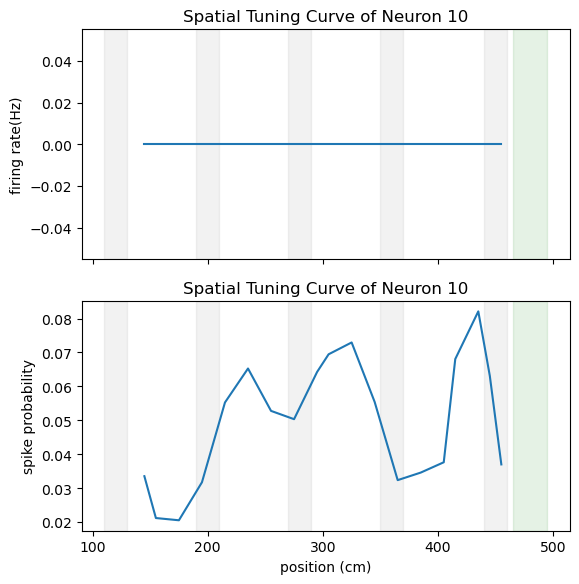

trial: 1 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


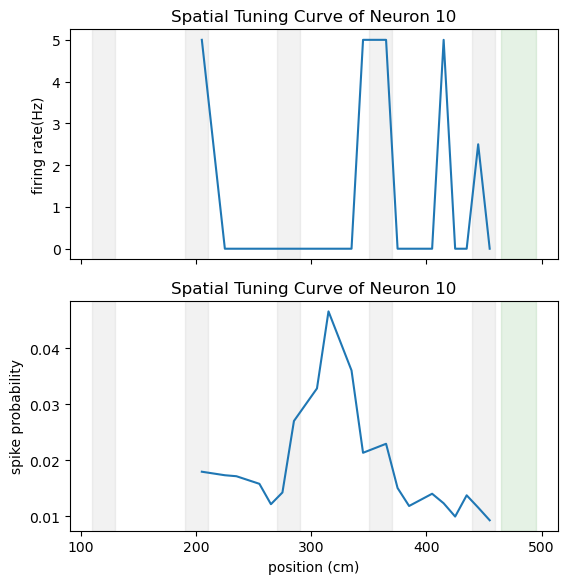

trial: 2 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


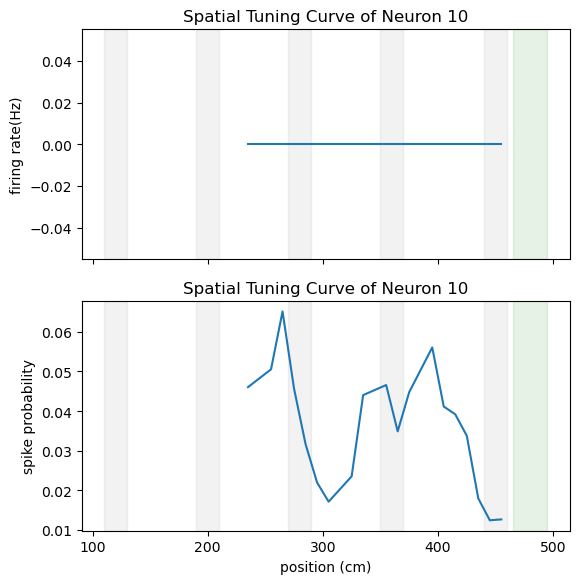

trial: 3 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


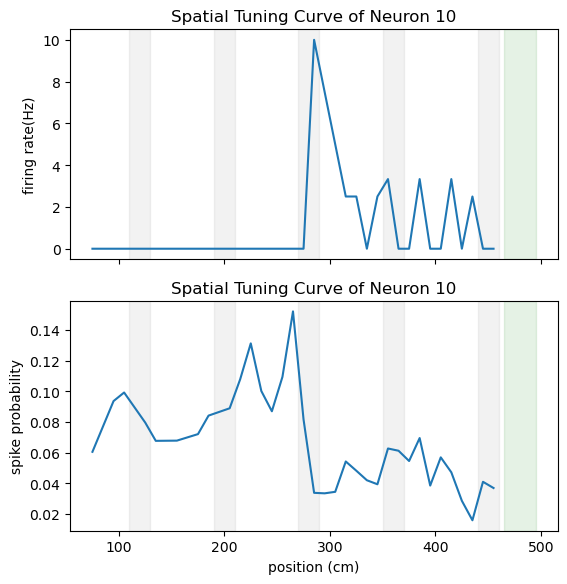

trial: 4 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


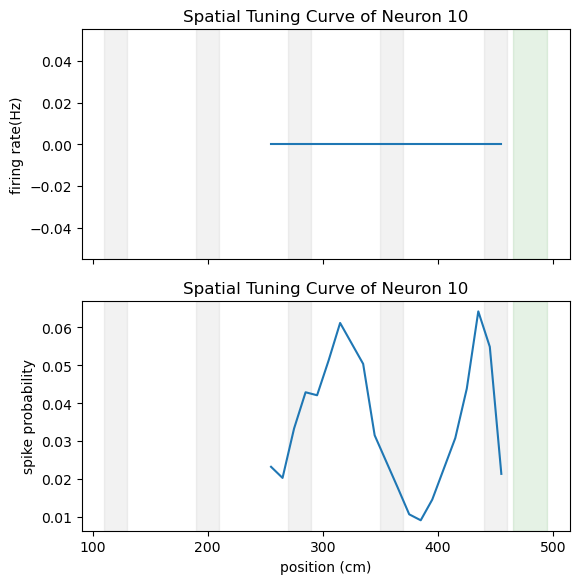

trial: 5 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


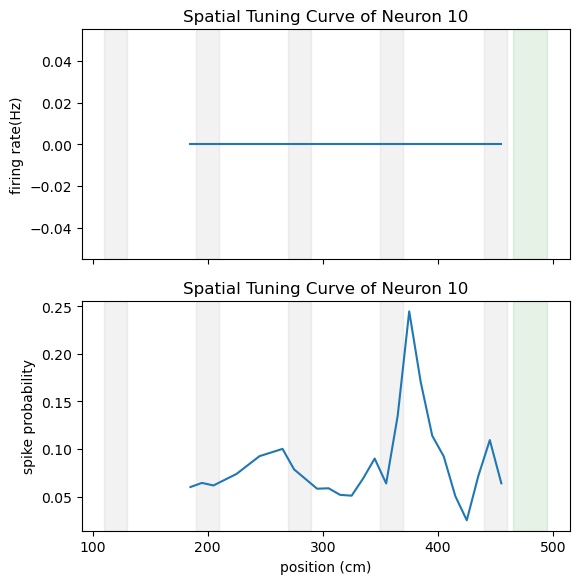

trial: 6 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


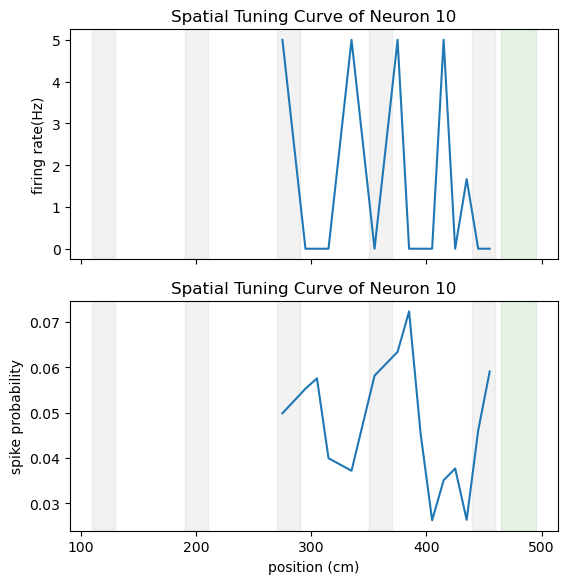

trial: 7 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


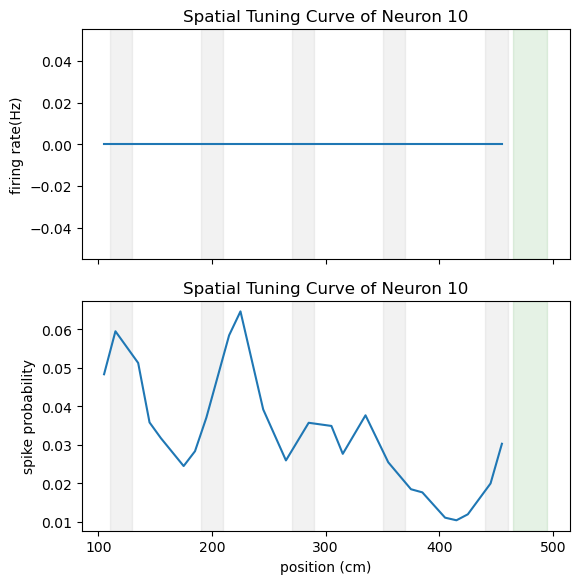

trial: 8 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


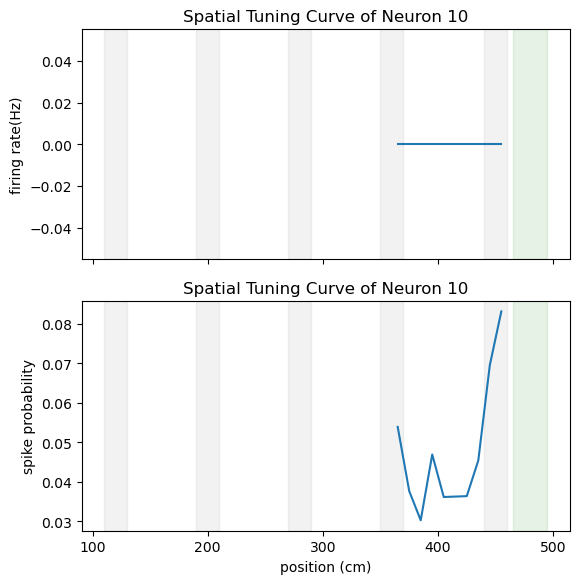

trial: 9 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


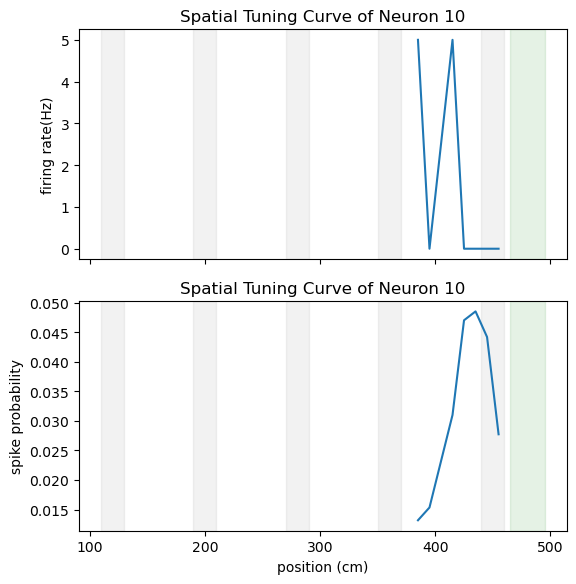

trial: 10 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


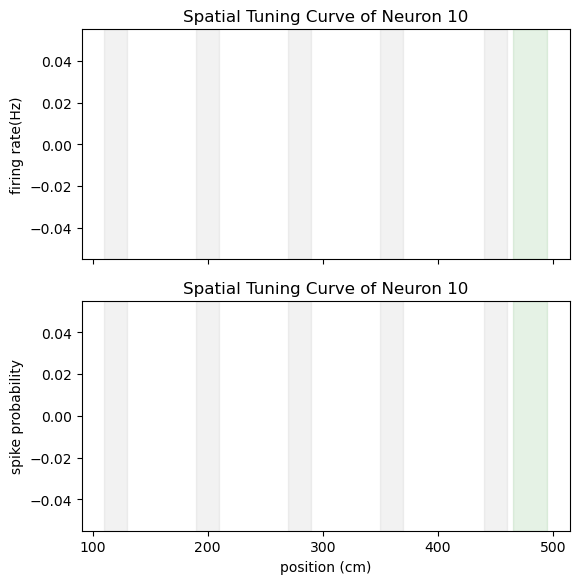

trial: 11 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


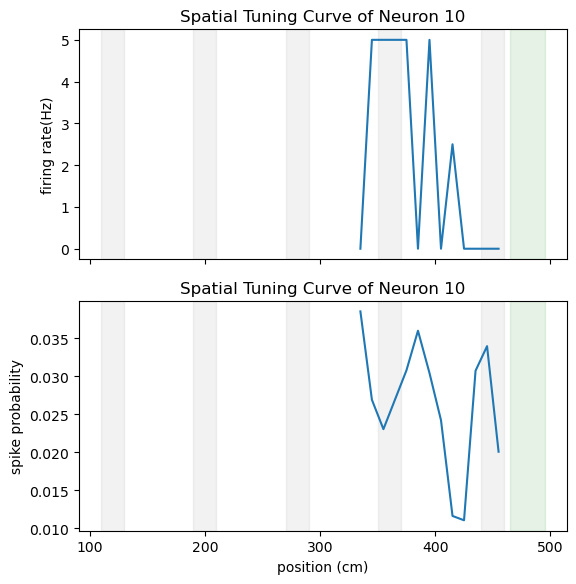

trial: 12 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


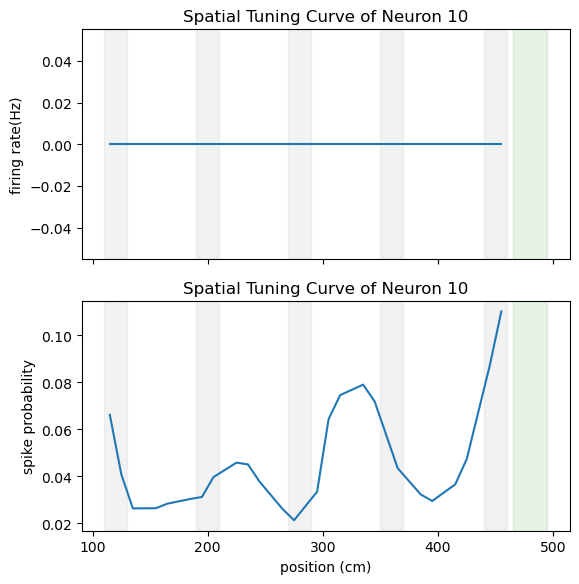

trial: 13 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


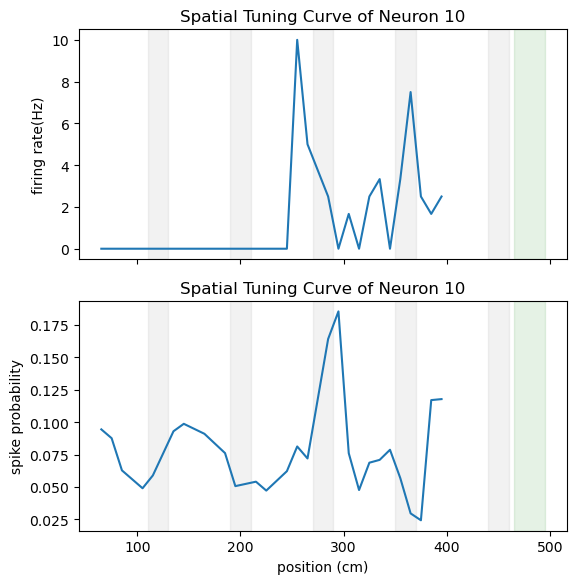

trial: 14 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


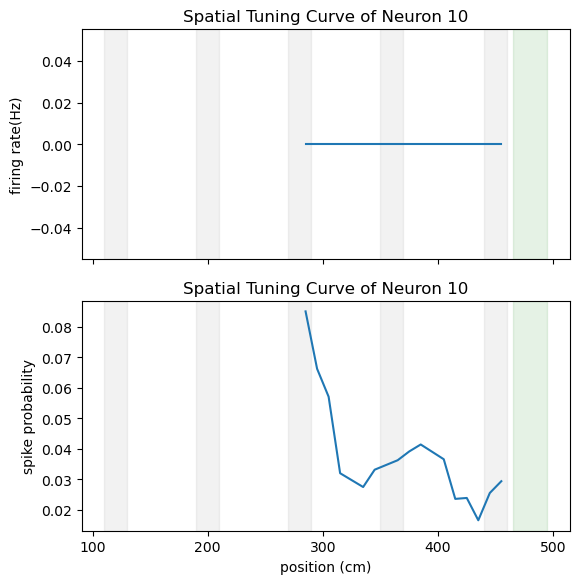

trial: 15 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


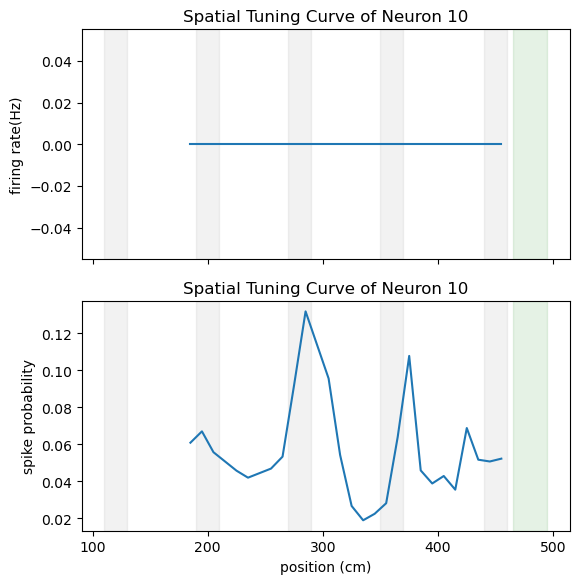

trial: 16 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


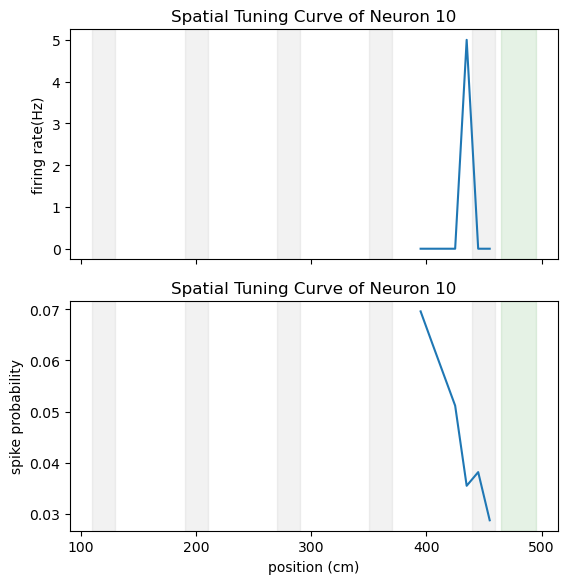

trial: 17 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


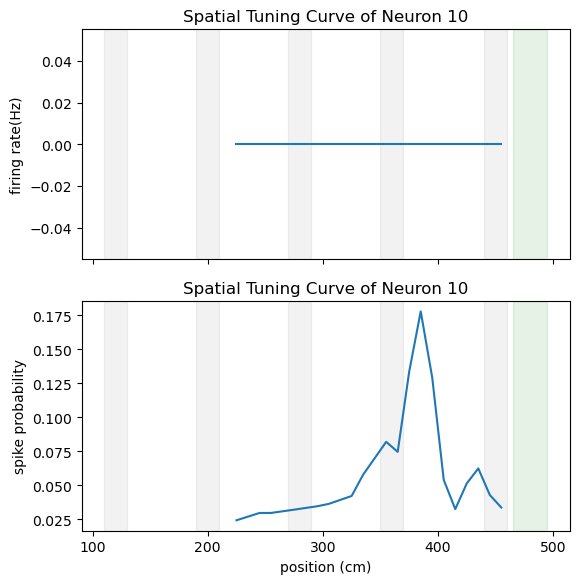

trial: 18 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


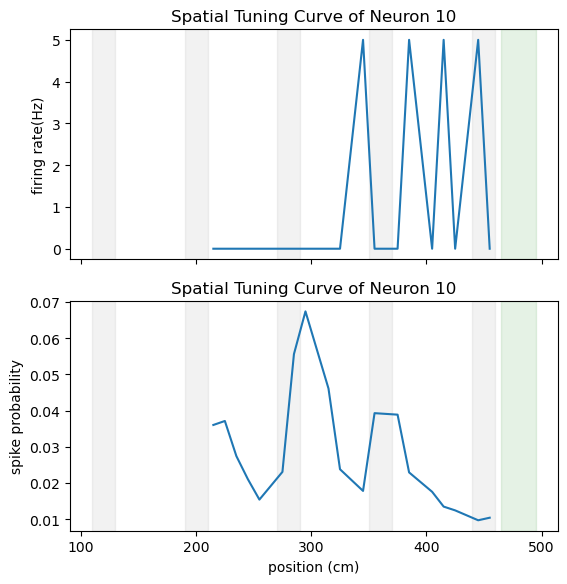

trial: 19 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


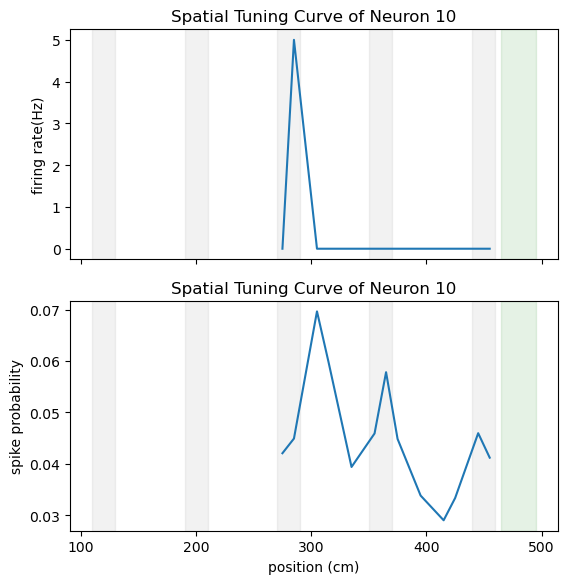

trial: 20 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


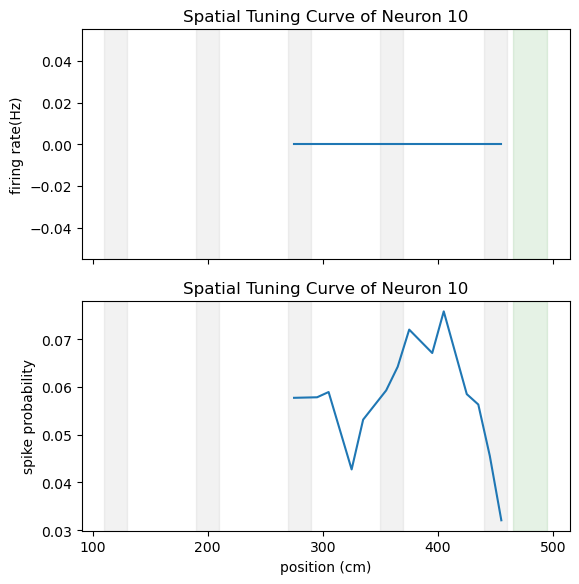

trial: 21 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


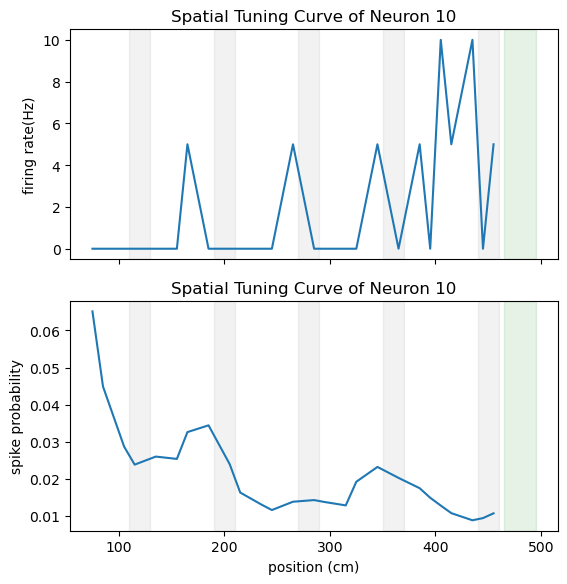

trial: 22 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


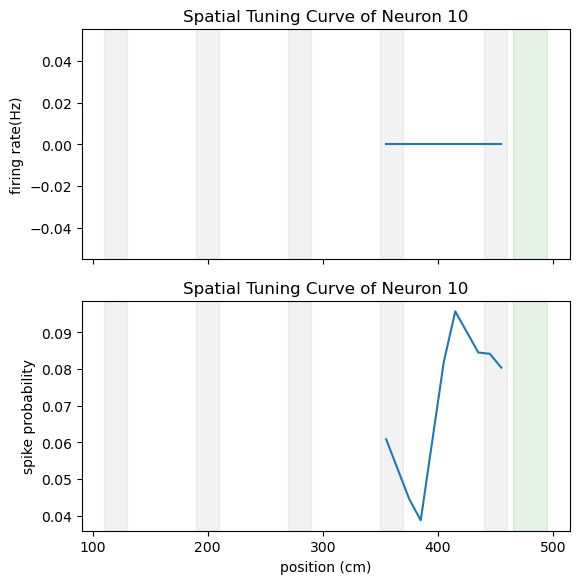

trial: 23 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


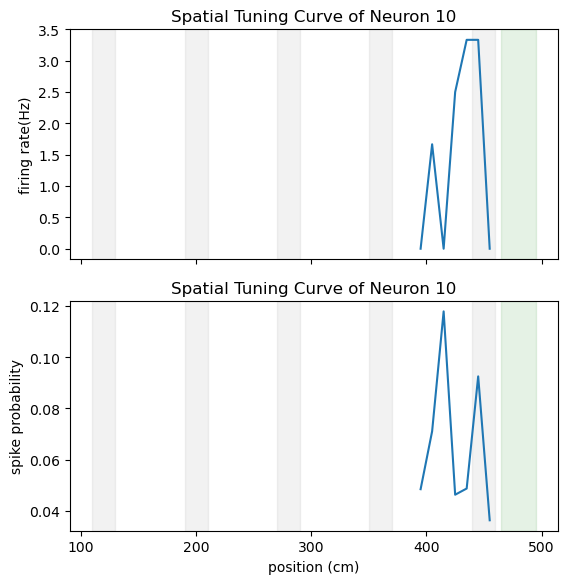

trial: 24 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


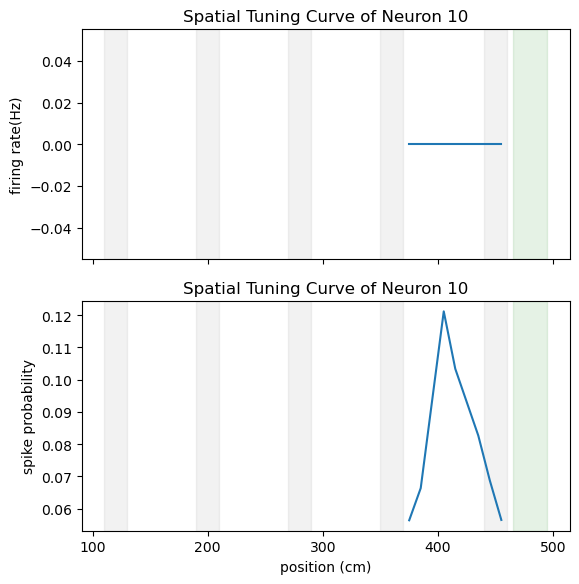

trial: 25 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


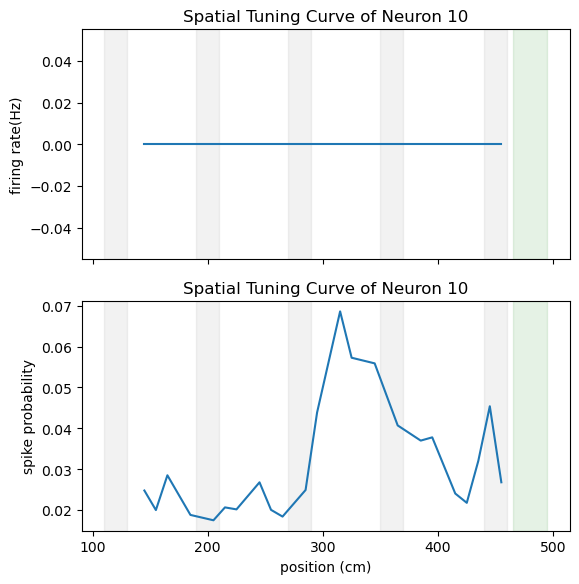

trial: 26 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


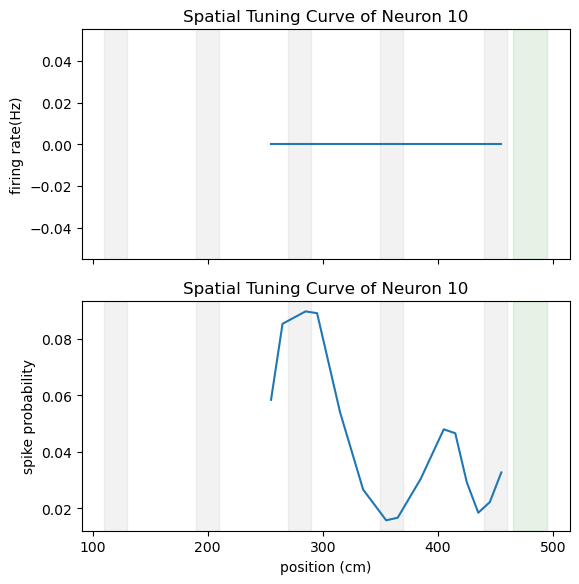

trial: 27 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


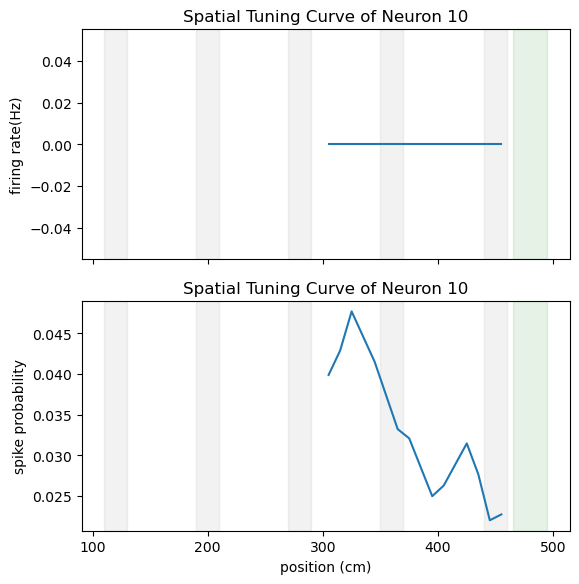

trial: 28 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


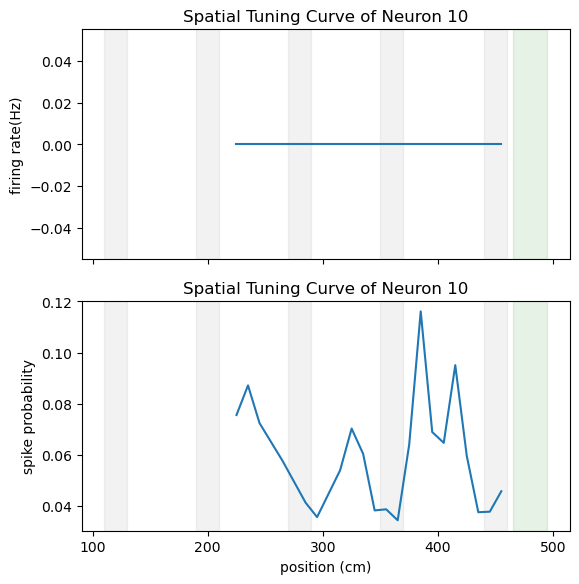

trial: 29 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


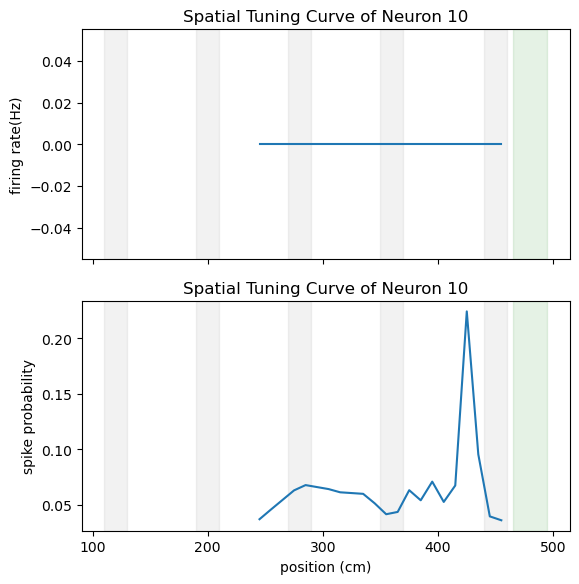

trial: 30 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


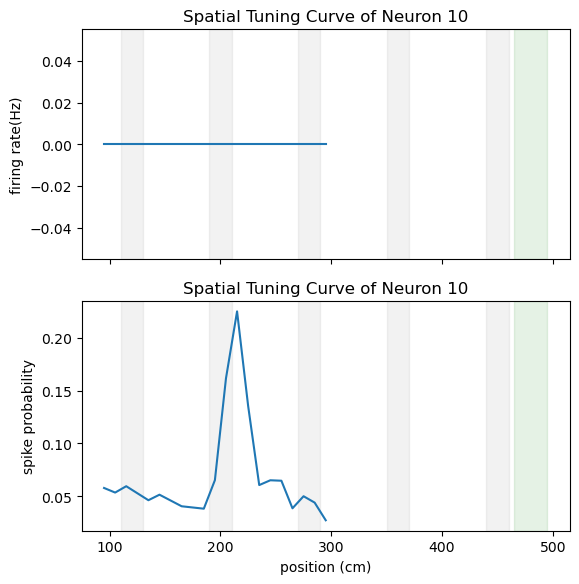

trial: 31 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


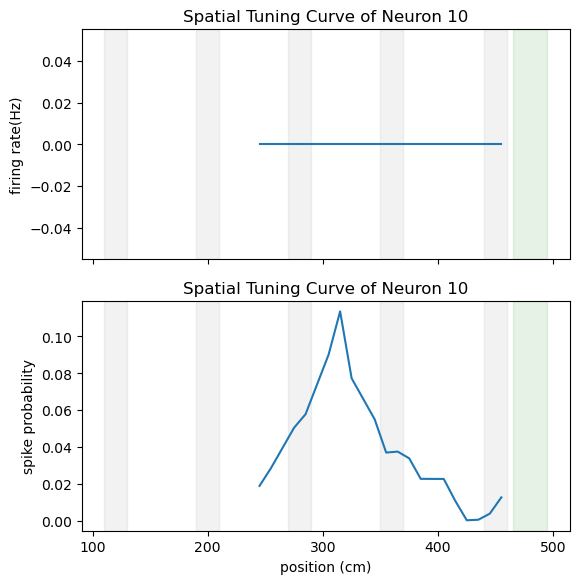

trial: 32 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


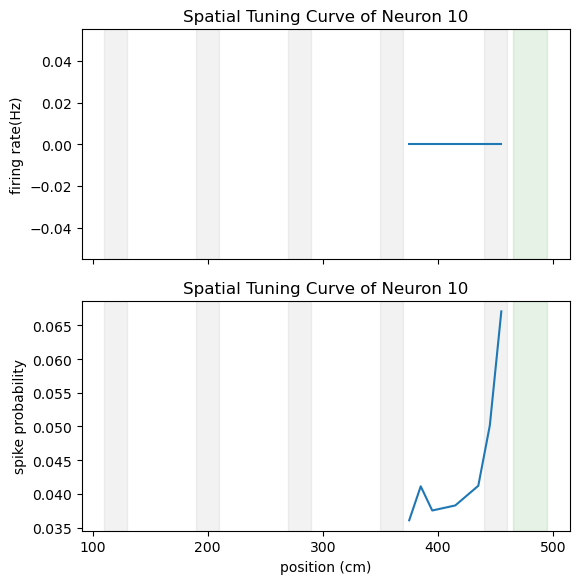

trial: 33 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


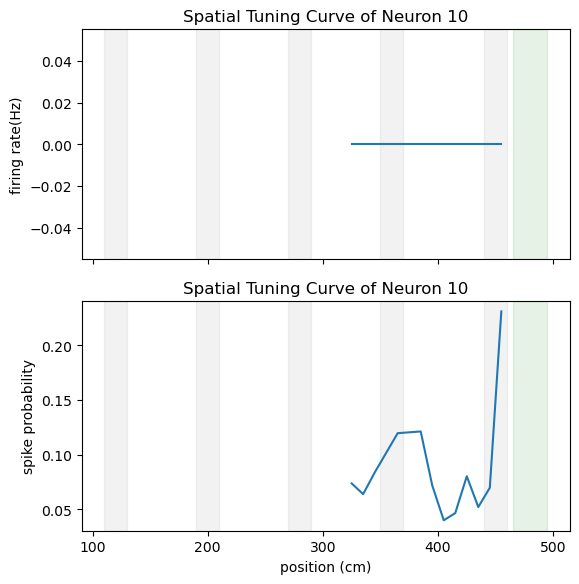

trial: 34 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


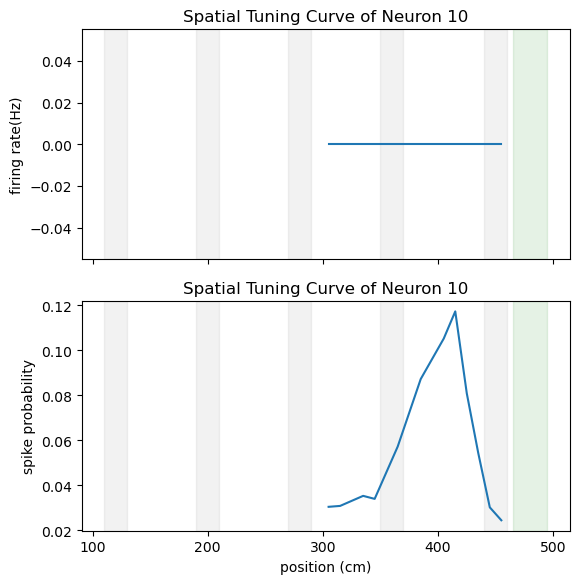

trial: 35 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


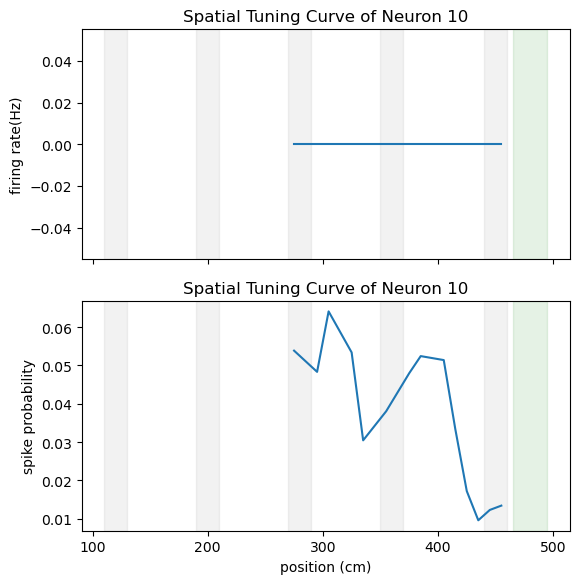

trial: 36 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


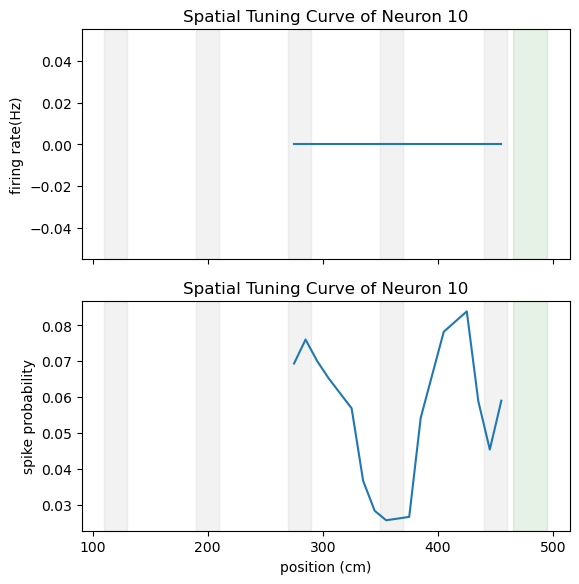

trial: 37 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


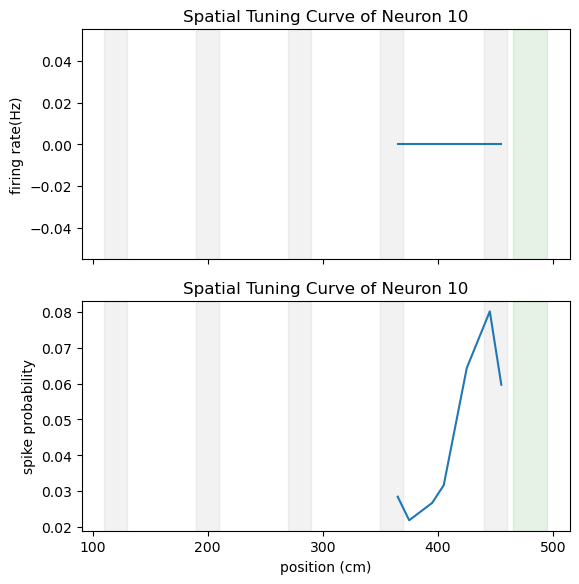

trial: 38 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


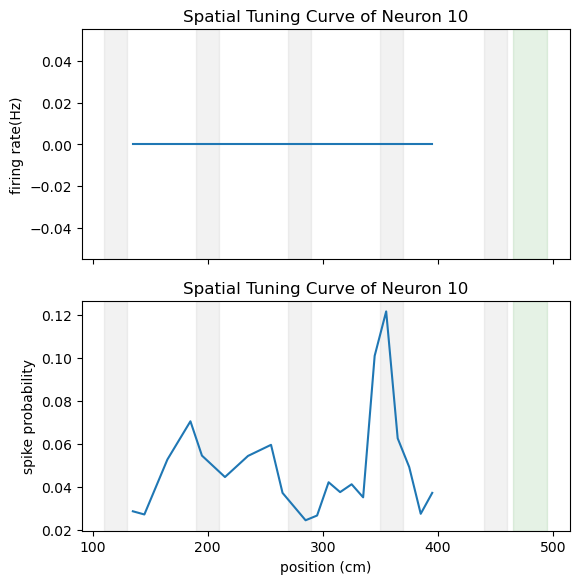

trial: 39 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


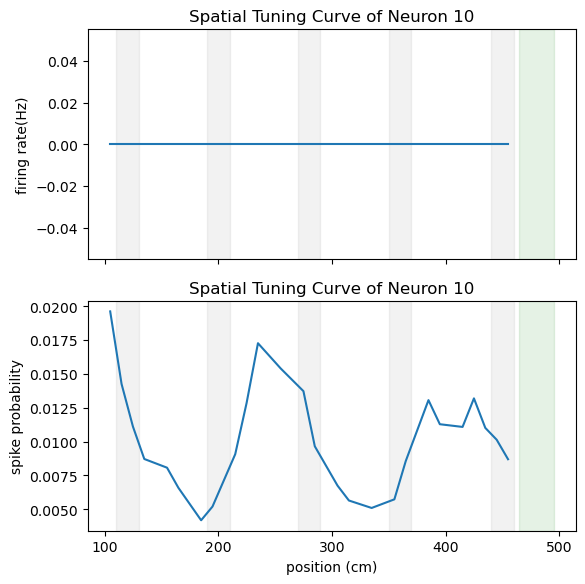

trial: 40 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


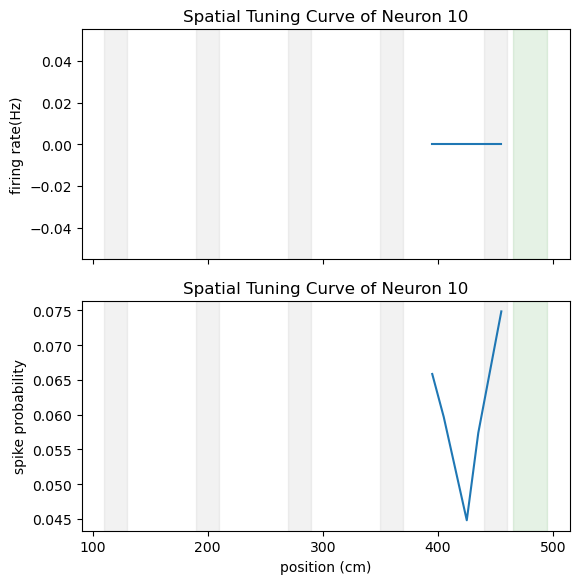

trial: 41 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


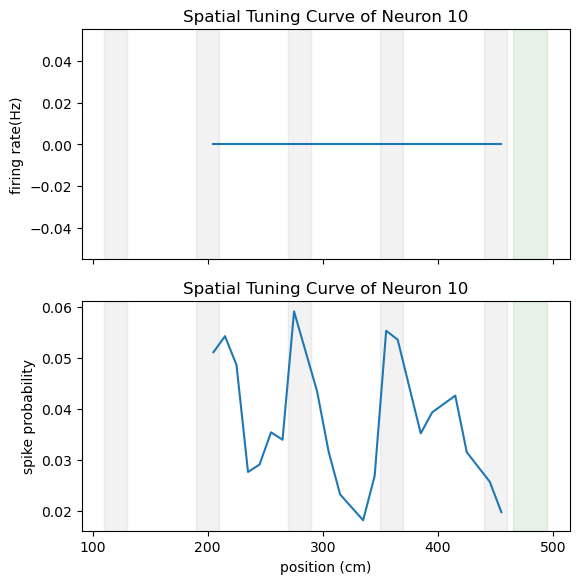

trial: 42 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


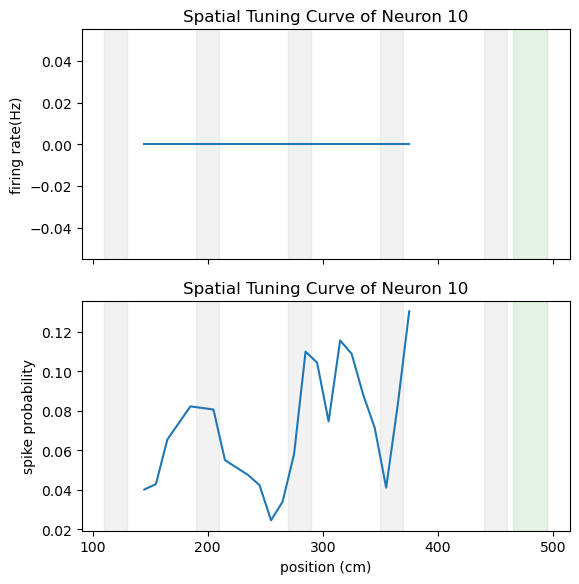

trial: 43 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


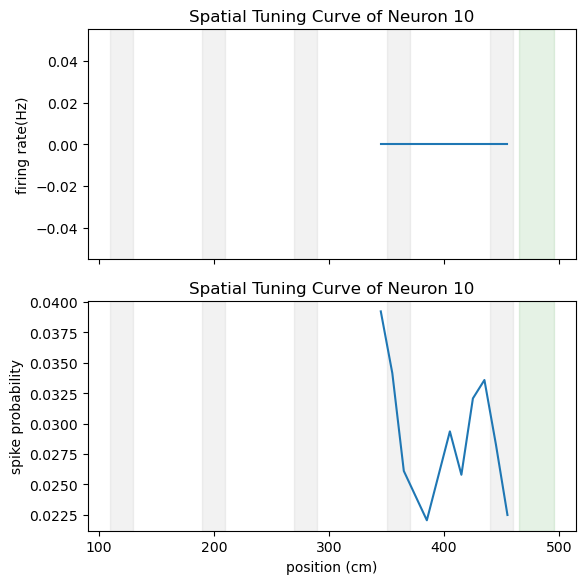

trial: 44 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


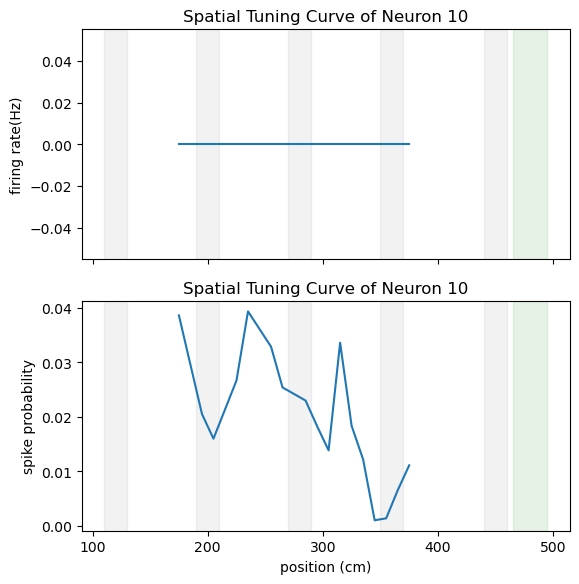

trial: 45 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


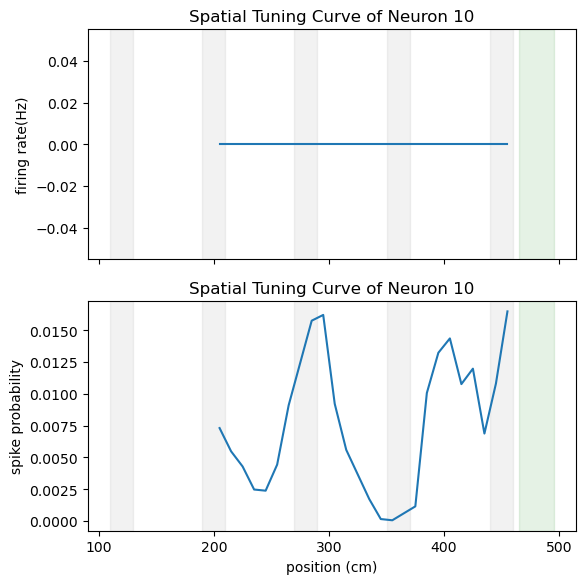

trial: 46 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


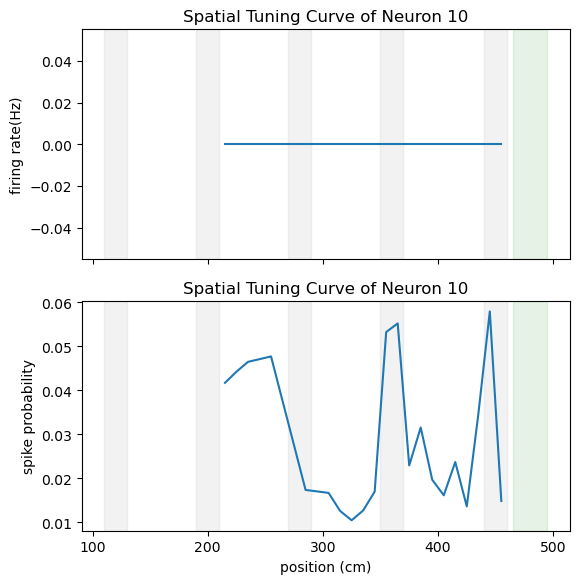

trial: 47 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


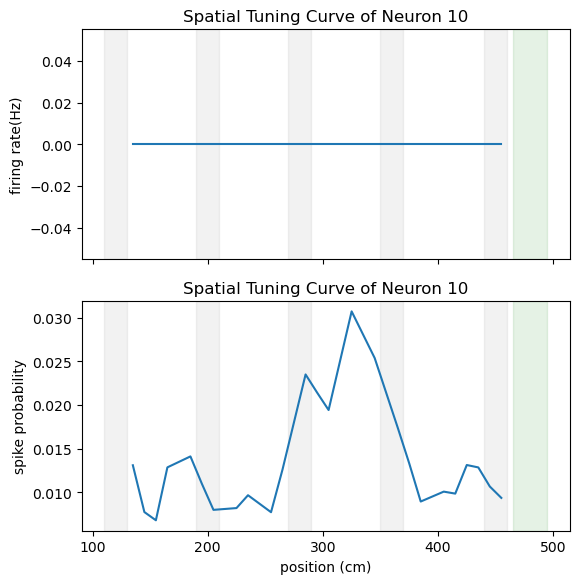

trial: 48 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


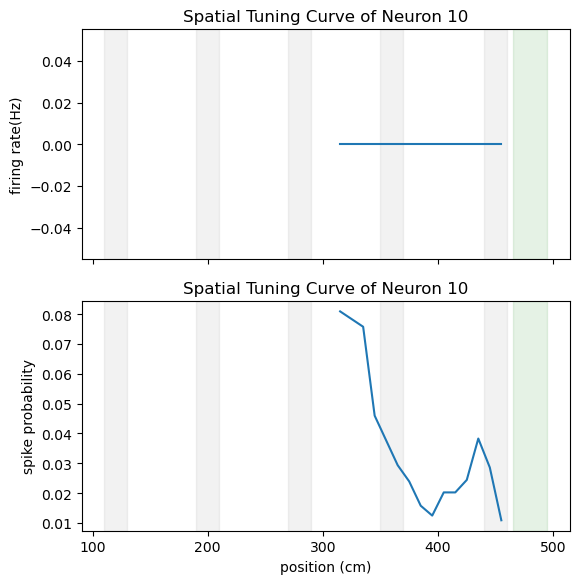

trial: 49 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


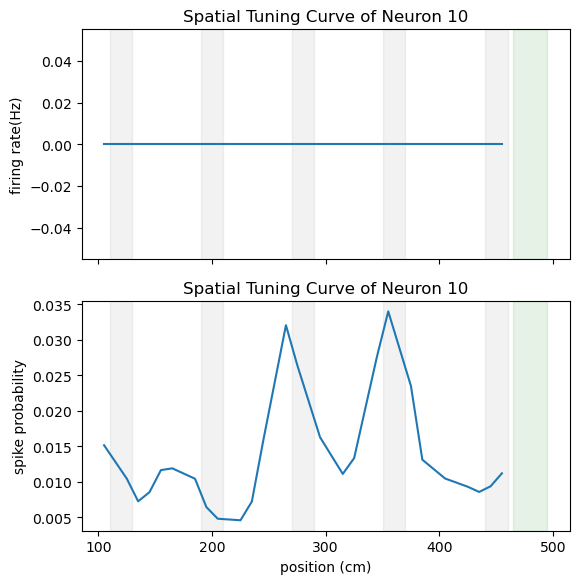

trial: 50 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


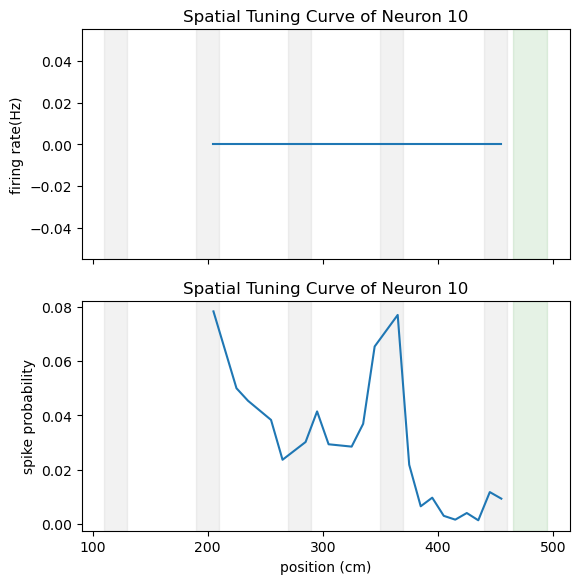

trial: 51 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


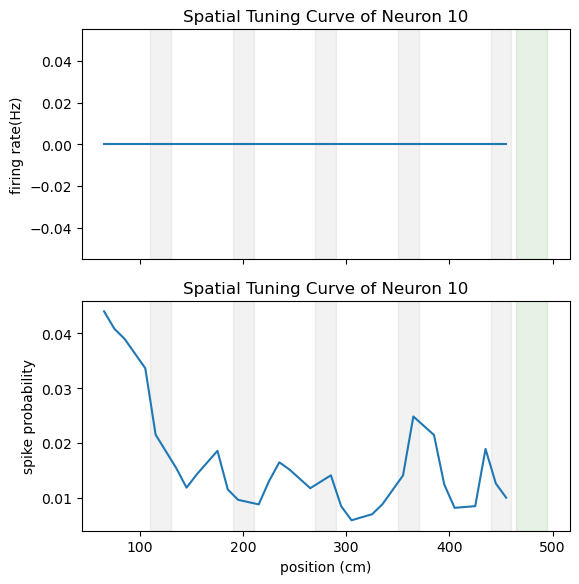

trial: 52 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


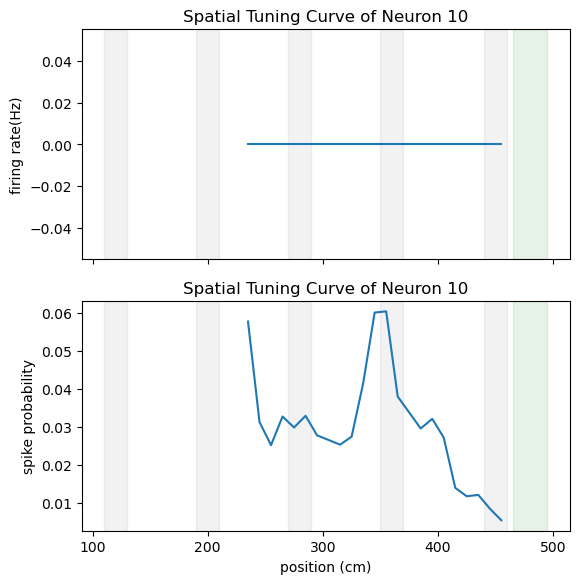

trial: 53 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


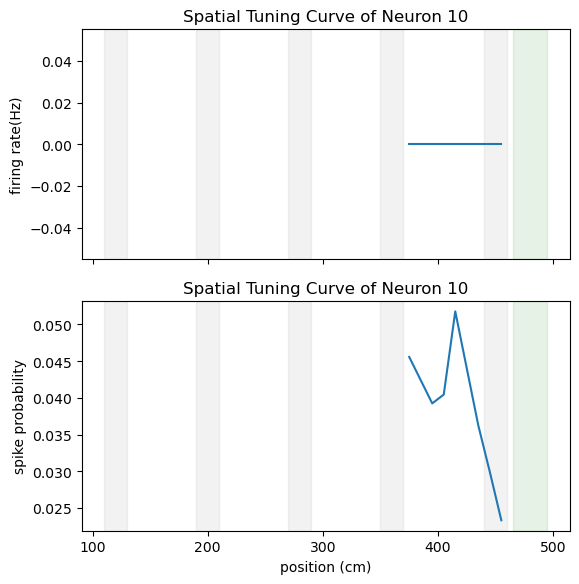

trial: 54 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


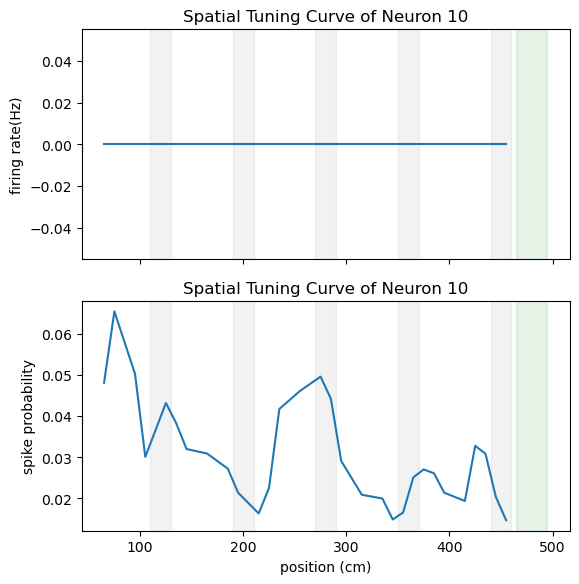

trial: 55 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


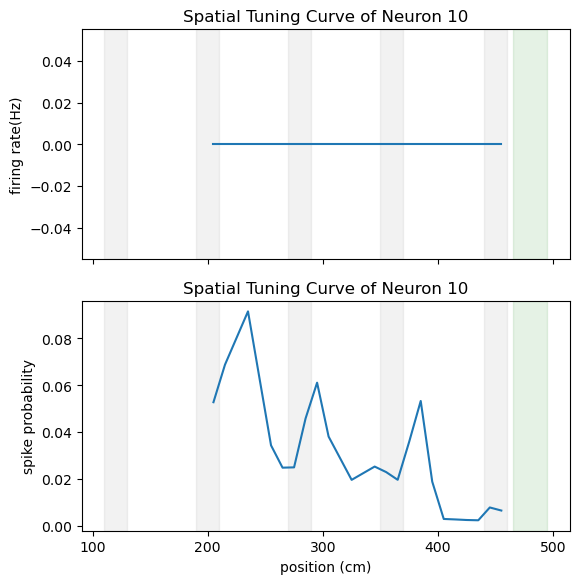

trial: 56 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


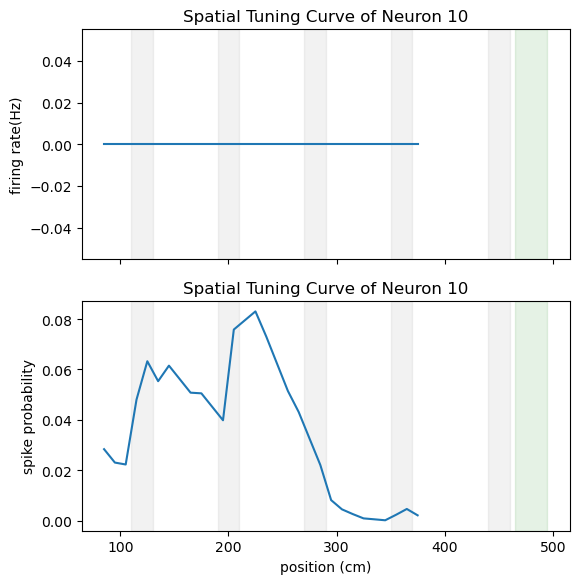

trial: 57 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


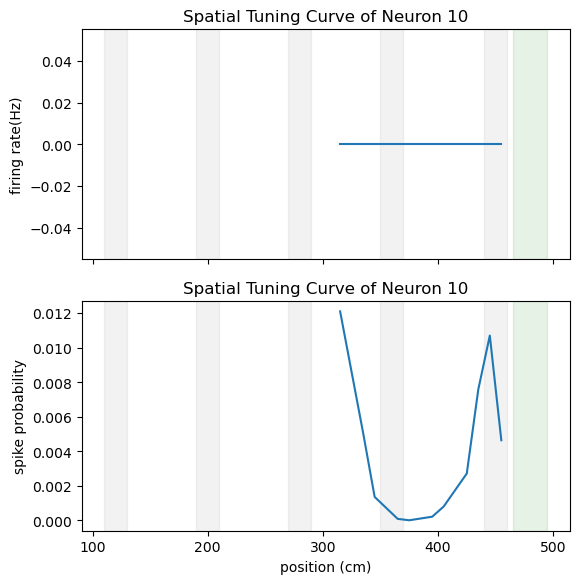

trial: 58 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


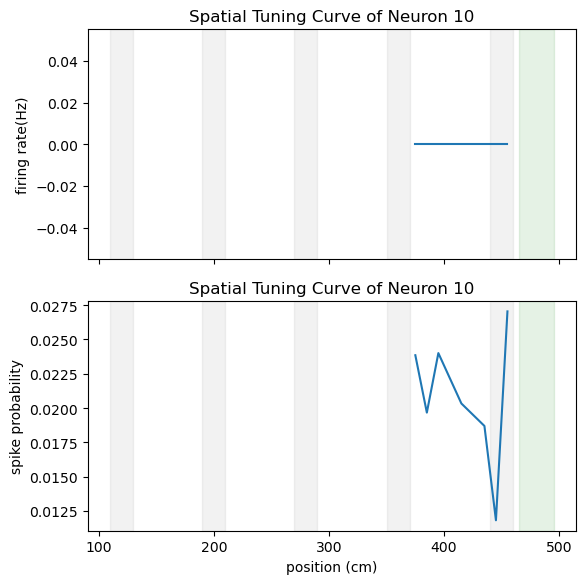

trial: 59 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


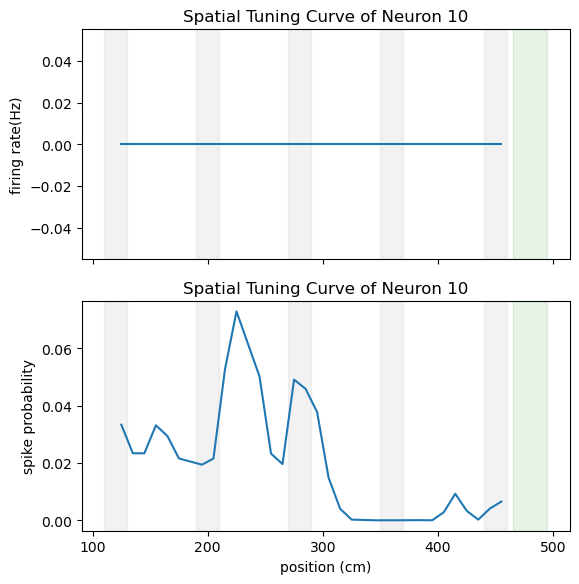

trial: 60 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


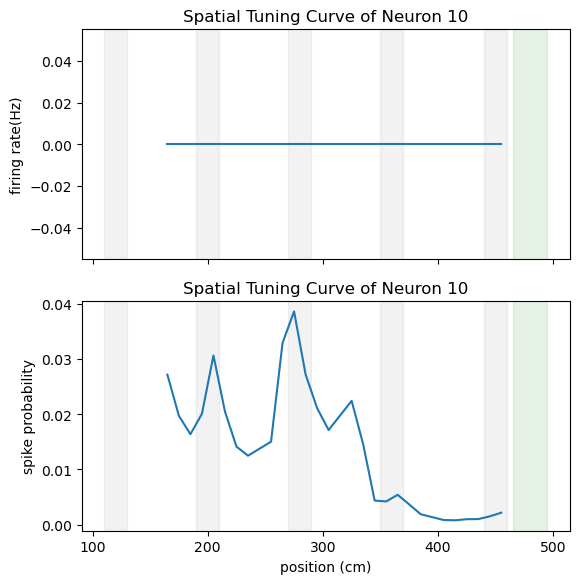

trial: 61 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


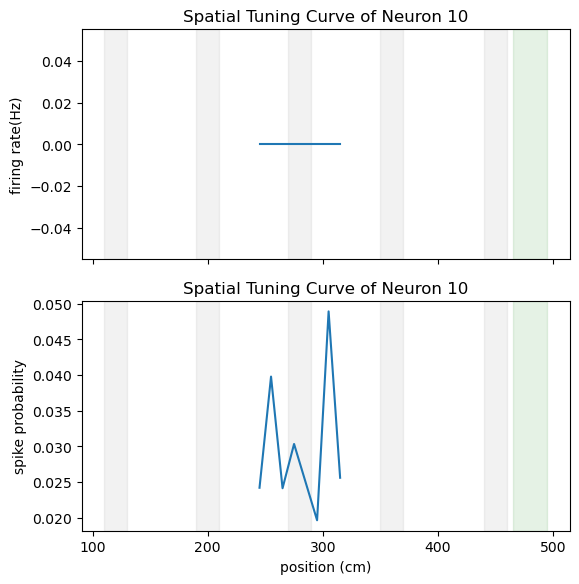

trial: 62 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


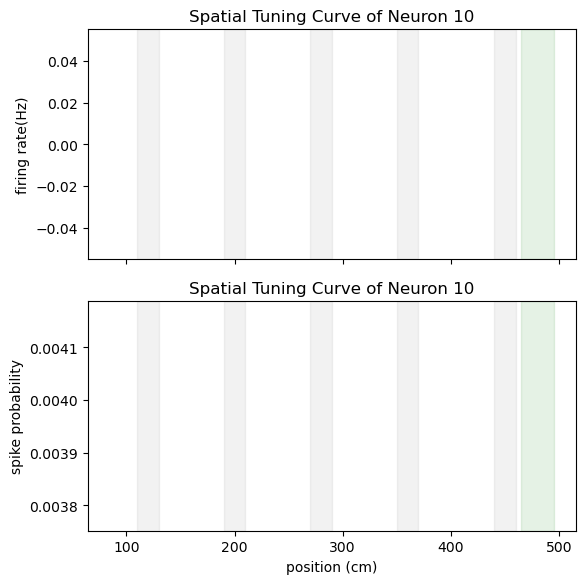

trial: 63 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


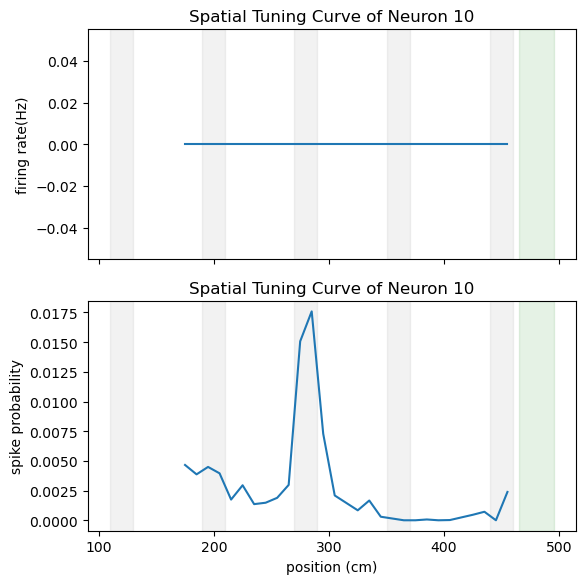

trial: 64 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


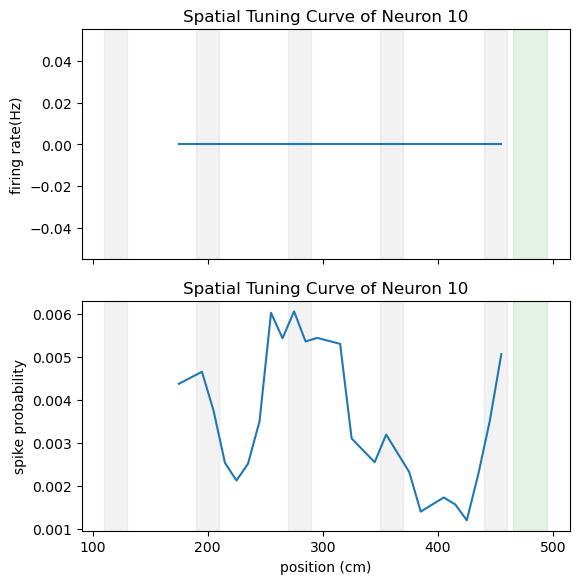

trial: 65 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


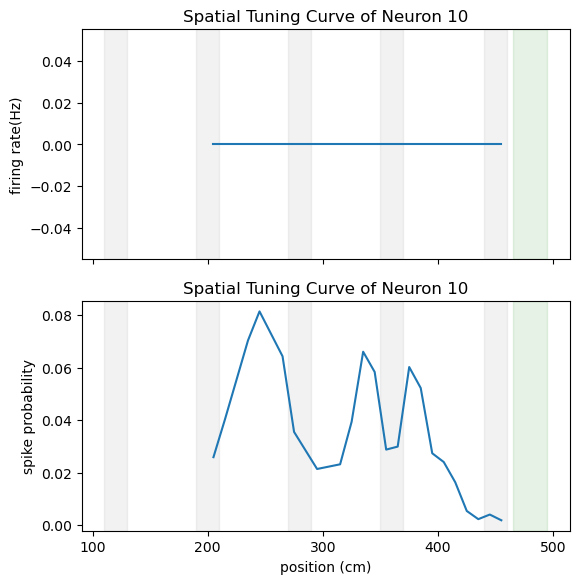

trial: 66 light


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


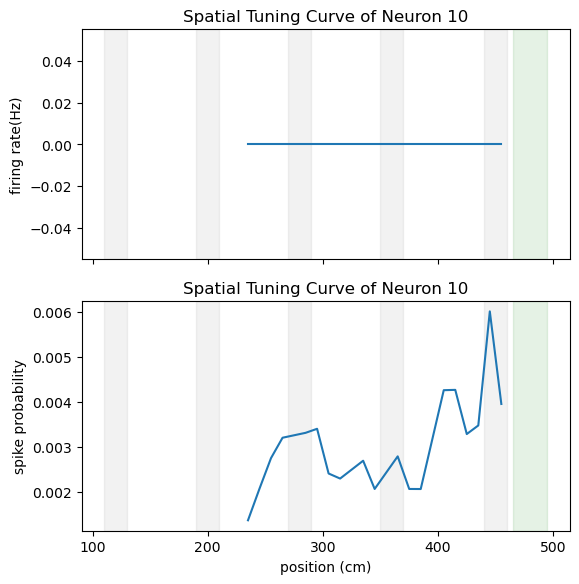

trial: 67 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


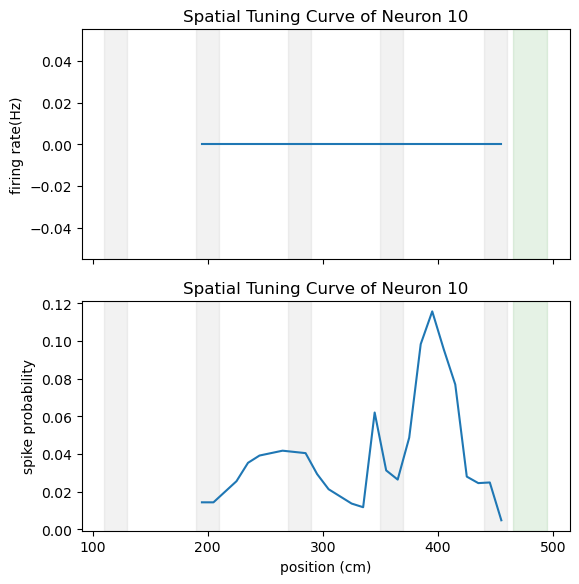

trial: 68 dark


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


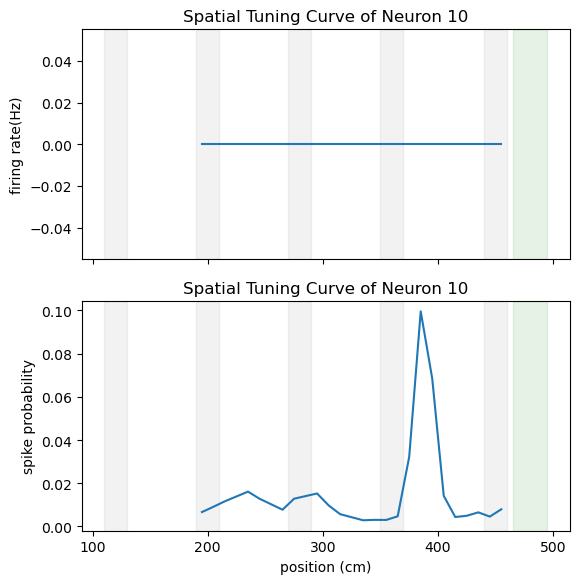

trial: 69 light


KeyboardInterrupt: 

In [20]:
num_trials, num_pbins, num_neurons = fr.shape

for trial in range(num_trials):
    if darktrials[trial] == 0:
        print("trial:", trial, 'light')
    else:
        print("trial:", trial, 'dark')

    spikes_pbin = u.posbinning_data(spikes, 'spikes', position_mtx_masked, 50, 0.2)

    # Generate Data Frame
    position_all_spikes = np.tile(np.arange(num_pbins), 1)
    data_all_spikes = spikes_pbin[trial,:,neuron_idx].flatten()

    df_spikes_trial = pd.DataFrame(
        {'position':position_all_spikes, 'activity':data_all_spikes}
    )


    spikeprob_pbin = u.posbinning_data(spikeprob, 'spikeprob', position_mtx_masked, 50, 0.2)

    # Generate Data Frame
    position_all_spikeprob = np.tile(np.arange(num_pbins), 1)
    data_all_spikeprob = spikeprob_pbin[trial,:,neuron_idx].flatten()
      
    df_spikeprob_trial = pd.DataFrame(
        {'position':position_all_spikeprob, 'activity':data_all_spikeprob}
    )




    # Initialise figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,6), sharex=True)
    fig.tight_layout(pad=2.5, h_pad=2)

    # Initialise figure settings
    ax_settings = {'title':'Spatial Tuning Curve of Neuron {}'.format(neuron_idx), 
                    'xlabel':'position (cm)',
                    'xticks':[-0.5, 9.5, 19.5, 29.5, 39.5, 49.5],
                    'xticklabels':[0, 100, 200, 300, 400, 500]}

    # Plot
    ax1 = sns.lineplot(data=df_spikes_trial, x ='position', y='activity', ax=ax1)
    ax2 = sns.lineplot(data=df_spikeprob_trial, x ='position', y='activity', ax=ax2)


    ax1.set(ylabel = 'firing rate(Hz)', **ax_settings)
    ax2.set(ylabel ='spike probability', **ax_settings)



    # Specify landmarks and reward zones
    landmark = [(10.5,12.5), (18.5,20.5), (26.5,28.5), (34.5,36.5), (43.5,45.5)]
    rewardzone = (46, 49)

    for coord in landmark:
        ax1.axvspan(coord[0], coord[1], alpha=0.1, color='grey')
        ax2.axvspan(coord[0], coord[1], alpha=0.1, color='grey')

    ax1.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')
    ax2.axvspan(rewardzone[0], rewardzone[1], alpha=0.1, color='green')
        
    plt.show()